In [9]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

In [188]:
import SimpleITK as sitk

# A file name that belongs to the series we want to read
file_name = "/Users/elisedonszelmann-lund/Downloads/anatomicalData_0001/001.dcm"
data_directory = "/Users/elisedonszelmann-lund/Downloads/anatomicalData_0001"

# Read the file's meta-information without reading bulk pixel data
file_reader = sitk.ImageFileReader()
file_reader.SetFileName(file_name)
file_reader.ReadImageInformation()

# Get the sorted file names, opens all files in the directory and reads the meta-information
# without reading the bulk pixel data
series_ID = file_reader.GetMetaData('0020|000e')
sorted_file_names = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(data_directory, series_ID)

# Read the bulk pixel data
data_img = sitk.ReadImage(sorted_file_names)
print(data_img.GetSize())
data_img.GetSpacing()

(256, 256, 160)


(1.0, 1.0, 0.9999999999999984)

In [226]:
import SimpleITK as sitk

# A file name that belongs to the series we want to read
file_name = "/Users/elisedonszelmann-lund/Downloads/anatomicalProbesEye_0002/coarse.S2.dcm"
data_directory = "/Users/elisedonszelmann-lund/Downloads/anatomicalProbesEye_0002"

# Read the file's meta-information without reading bulk pixel data
file_reader = sitk.ImageFileReader()
file_reader.SetFileName(file_name)
file_reader.ReadImageInformation()

# Get the sorted file names, opens all files in the directory and reads the meta-information
# without reading the bulk pixel data
series_ID = file_reader.GetMetaData('0020|000e')
sorted_file_names = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(data_directory, series_ID)

# Read the bulk pixel data
probe_img = sitk.ReadImage(sorted_file_names)

print(probe_img.GetSize())
print(probe_img.GetDimension())
print(probe_img.GetDirection())
print(probe_img.GetSpacing())
print(probe_img.GetOrigin())

(128, 128, 3)
3
(0.9965420655686615, -0.04514367796209914, -0.06975643262237675, 0.08308978007038091, 0.5414337120624997, 0.8366275299618571, 4.0468146569882294e-08, -0.8395305734648839, 0.54331244806071)
(2.0, 2.0, 5.249998796434068)
(-171.0125579834, -111.731590271, 136.807220458984)


In [277]:
orientation_filter = sitk.DICOMOrientImageFilter()
orientation_filter.SetDesiredCoordinateOrientation("LPS")
reoriented = orientation_filter.Execute(data_img)

new_spacing = [2.0, 2.0, 5.25] 
interpolator = sitk.sitkLinear
new_size = [int(round(osz*ospc/nspc)) for osz,ospc,nspc in zip(reoriented.GetSize(), reoriented.GetSpacing(), new_spacing)]
minimum_value = sitk.GetArrayFromImage(reoriented).min()

resampled = sitk.Resample(reoriented,
                          new_size,
                          sitk.Transform(),
                          sitk.sitkLinear,
                          reoriented.GetOrigin(),
                          new_spacing,
                          reoriented.GetDirection(),
                          int(minimum_value),
                          reoriented.GetPixelID())

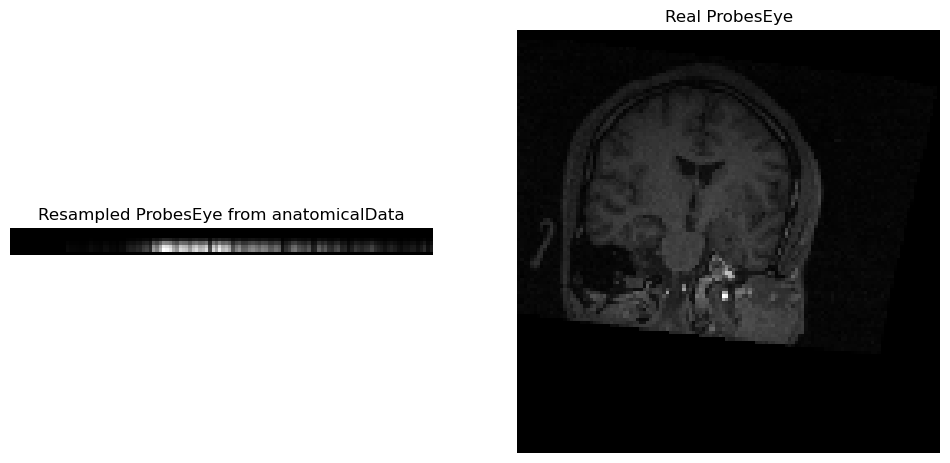

In [281]:
import pydicom
slice_image = resampled[:, :, 10]
slice_array = sitk.GetArrayFromImage(slice_image)

real_probes = pydicom.dcmread("/Users/elisedonszelmann-lund/Downloads/anatomicalProbesEye_0001/coarse.S2.dcm")
probes_array = real_probes.pixel_array

plt.figure(figsize=(12, 6))  # Set the figure size

plt.subplot(1, 2, 1)
plt.imshow(slice_array, cmap='gray')
plt.title("Resampled ProbesEye from anatomicalData")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(probes_array, cmap='gray')
plt.title("Real ProbesEye")
plt.axis('off')

plt.show()

In [272]:
def resample_img(data_img, probe_img, out_spacing, is_label=False):
    
    # Resample images to out_spacing with SimpleITK
    original_spacing = data_img.GetSpacing()
    original_size = data_img.GetSize()

    out_size = [
        int(np.round(original_size[0] * (original_spacing[0] / out_spacing[0]))),
        int(np.round(original_size[1] * (original_spacing[1] / out_spacing[1]))),
        int(np.round(original_size[2] * (original_spacing[2] / out_spacing[2])))]

    # out_size = [
    # int(np.round(original_size[0] * (original_spacing[0] / out_spacing[0]))),
    # int(np.round(original_size[1] * (original_spacing[1] / out_spacing[1]))),
    # 3]


    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)

    # resample.SetOutputDirection(data_img.GetDirection())
    # resample.SetOutputOrigin(data_img.GetOrigin())

    resample.SetOutputDirection(probe_img.GetDirection())
    resample.SetOutputOrigin(probe_img.GetOrigin())

    


    resample.SetDefaultPixelValue(probe_img.GetPixelIDValue())


######



# INPUT:
#  data_img - anatomicalData SITK 
# out_spacing - anatomicalProbesEye SITK spacing dimentions
resampled_sitk_img = resample_img(data_img, probe_img, out_spacing=[2.0, 2.0, 1.0], is_label=False)


print(resampled_sitk_img.GetDimension())
print(type(resampled_sitk_img))
print(resampled_sitk_img.GetSize())


AttributeError: 'NoneType' object has no attribute 'GetDimension'

In [264]:
import pydicom
slice_image = resampled_sitk_img[:, :, 50]
slice_array = sitk.GetArrayFromImage(slice_image)

real_probes = pydicom.dcmread("/Users/elisedonszelmann-lund/Downloads/anatomicalProbesEye_0001/coarse.S2.dcm")
probes_array = real_probes.pixel_array

plt.figure(figsize=(12, 6))  # Set the figure size

plt.subplot(1, 2, 1)
plt.imshow(slice_array, cmap='gray')
plt.title("Resampled ProbesEye from anatomicalData")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(probes_array, cmap='gray')
plt.title("Real ProbesEye")
plt.axis('off')

plt.show()


TypeError: 'NoneType' object is not subscriptable